# Data Analysis Template for Semantic Segmentation (Deep Learning)

## Scope
This notebook is a complete, high-standard template for image data analysis before training a semantic segmentation model.
It is designed so you can fill in the implementation step by step.

## Dataset Assumptions
- Input channels (5): **NIR, Red, Green, Blue, Normalized Height**
- Target classes (8):
  1. Building
  2. Impervious_Surface
  3. Cropland
  4. Intensive_Culture
  5. Grassland_Garden
  6. Tree_Canopy
  7. Water
  8. Railway

## How To Use This Template
1. Keep all sections and fill each code cell marked with `TODO`.
2. Save every intermediate result to make experiments reproducible.
3. At the end, summarize findings in a short model-readiness report.

## Expected Output Artifacts
- Dataset inventory and integrity checks
- Channel statistics and class distribution reports
- Correlation matrix and feature-importance analysis
- Data-quality and risk assessment for model training

In [67]:
# ================================================
# TODO: Environment setup and imports
# ================================================

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import os
import rasterio
import re
from pathlib import Path
from cycler import cycler

# --- 1. Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

# --- 2. Plot style + Unified Color Schema ---
plt.style.use('dark_background')

# Alternativen wären "Set2" (etwas pastelliger) oder "Dark2" (dunkler).
NUM_CLASSES = 8
plot_palette = sns.color_palette("tab10", n_colors=NUM_CLASSES)

PALETTE_HEX = plot_palette.as_hex()

MASK_CMAP = ListedColormap(plot_palette)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.alpha": 0.35,
    "axes.prop_cycle": cycler(color=PALETTE_HEX),
})

# Seaborn auf dieselbe Palette zwingen
sns.set_palette(PALETTE_HEX)

# --- 3. Global analysis settings ---
CONFIG = {
    "SAMPLE_SIZE": 100000,
    "HIST_BINS": 100,
    "VMAX_IMAGE": 6500,
    "OUTPUT_DIR": "./reports/figures",
    "CLASS_NAMES": {
        1: "Building",
        2: "Impervious_Surface",
        3: "Cropland",
        4: "Intensive_Culture",
        5: "Grassland_Garden",
        6: "Tree_Canopy",
        7: "Water",
        8: "Railway",
    },
    "CMAP_IMAGE": "gray",
    "CMAP_MASK": MASK_CMAP,  # Nun perfekt synchronisiert mit den Plots!
    "PALETTE": PALETTE_HEX,
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


## Plot Style Preview

Use this cell to quickly inspect the notebook style and color palette before running the analysis.

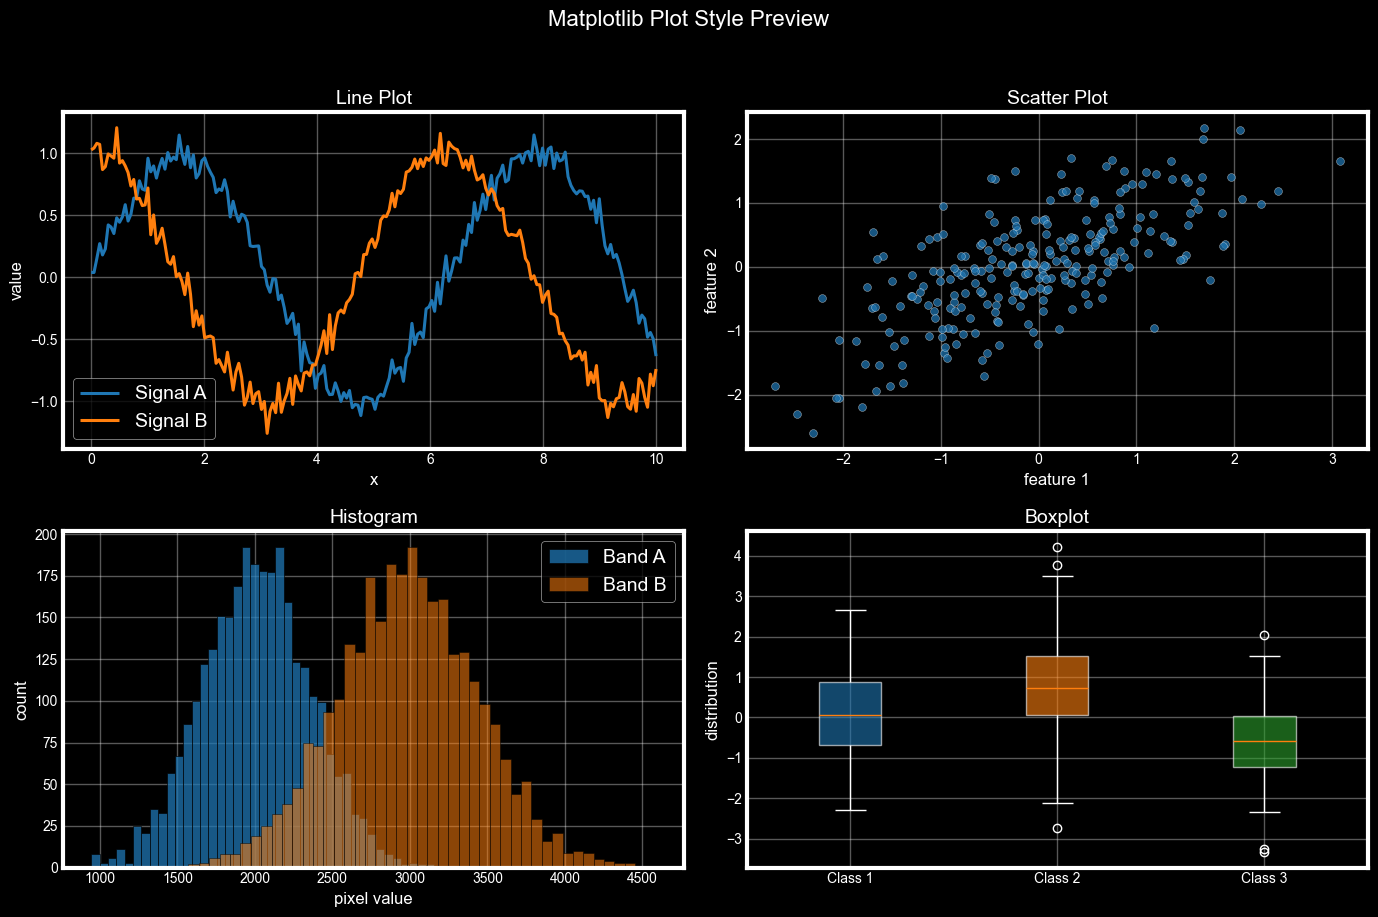

Active palette: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']


In [68]:
# Matplotlib-only style preview: line, scatter, histogram, boxplot

np.random.seed(42)
colors = CONFIG["PALETTE"]

x = np.linspace(0, 10, 200)
y1 = np.sin(x) + 0.08 * np.random.randn(x.size)
y2 = np.cos(x) + 0.08 * np.random.randn(x.size)

scatter_x = np.random.normal(loc=0.0, scale=1.0, size=250)
scatter_y = 0.65 * scatter_x + np.random.normal(loc=0.0, scale=0.65, size=250)

d1 = np.random.normal(loc=2000, scale=350, size=3000)
d2 = np.random.normal(loc=3000, scale=450, size=3000)

box_data = [
    np.random.normal(0.0, 1.0, 180),
    np.random.normal(0.8, 1.1, 180),
    np.random.normal(-0.6, 0.9, 180),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Line plot
axes[0, 0].plot(x, y1, linewidth=2.2, label="Signal A", color=colors[0])
axes[0, 0].plot(x, y2, linewidth=2.2, label="Signal B", color=colors[1])
axes[0, 0].set_title("Line Plot")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("value")
axes[0, 0].legend(frameon=True)

# 2) Scatter plot
axes[0, 1].scatter(scatter_x, scatter_y, s=32, alpha=0.72, color=colors[0], edgecolor="white", linewidth=0.3)
axes[0, 1].set_title("Scatter Plot")
axes[0, 1].set_xlabel("feature 1")
axes[0, 1].set_ylabel("feature 2")

# 3) Histogram
axes[1, 0].hist(d1, bins=45, alpha=0.75, label="Band A", color=colors[0], edgecolor="black", linewidth=0.6)
axes[1, 0].hist(d2, bins=45, alpha=0.55, label="Band B", color=colors[1], edgecolor="black", linewidth=0.6)
axes[1, 0].set_title("Histogram")
axes[1, 0].set_xlabel("pixel value")
axes[1, 0].set_ylabel("count")
axes[1, 0].legend(frameon=True)

# 4) Boxplot
bp = axes[1, 1].boxplot(box_data, patch_artist=True, tick_labels=["Class 1", "Class 2", "Class 3"])
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[i])
    patch.set_alpha(0.6)
axes[1, 1].set_title("Boxplot")
axes[1, 1].set_ylabel("distribution")

fig.suptitle("Matplotlib Plot Style Preview", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Active palette:", CONFIG["PALETTE"])

## Notebook Roadmap

This template is organized into the following analysis blocks:
1. Dataset inventory and integrity
2. Raster metadata and geospatial consistency
3. Visual sanity checks
4. Descriptive statistics (channels and labels)
5. Missing data and NoData quality
6. Correlation matrix and feature redundancy
7. Feature importance for model-relevant signals
8. Split quality, leakage checks, and robustness
9. Outlier and hard-case mining
10. Final model-readiness report

For each code cell: replace TODO comments with your implementation and save outputs.

## 1) Dataset Inventory and Integrity

**Goal:** prove that raw data is complete, uniquely paired, and technically readable before any modeling.

### Minimum checks
- File counts and image-mask pairing
- Duplicate file detection (name and content hash)
- Corrupt/unreadable file detection
- Resolution consistency and expected channel count
- Class-ID validity in masks (expected: 1 to 8)

In [11]:
# Compact example: pair-level inventory dataframe


# Use file lists from Cell 3; fallback to local paths if needed

root_path = "A:/STUDIUM/06_Fruelingssemester26/BA/"
images_path = os.path.join(root_path, "data/aerial/Buffered_images/images")
masks_path = os.path.join(root_path, "data/aerial/Buffered_images/masks")
img_files = sorted([os.path.join(images_path, f) for f in os.listdir(images_path) if f.endswith(".tif")])
mask_files = sorted([os.path.join(masks_path, f) for f in os.listdir(masks_path) if f.endswith(".tif")])

def tile_id(file_path):
    s = Path(file_path).stem.lower()
    s = re.sub(r"^(clipped_stacked_buffered_|mask_)", "", s)
    return s

def readable(file_path):
    if file_path is None or pd.isna(file_path):
        return False
    try:
        with rasterio.open(file_path):
            return True
    except Exception:
        return False

image_df = pd.DataFrame({"image_file": img_files})
image_df["tile_id"] = image_df["image_file"].map(tile_id)

mask_df = pd.DataFrame({"mask_file": mask_files})
mask_df["tile_id"] = mask_df["mask_file"].map(tile_id)

pair_df = image_df.merge(mask_df, on="tile_id", how="outer", indicator=True)
pair_df["pair_status"] = pair_df["_merge"].map({"both": "ok", "left_only": "missing_mask", "right_only": "missing_image"})
pair_df = pair_df.drop(columns=["_merge"])

pair_df["image_file_size"] = pair_df["image_file"].map(lambda f: os.path.getsize(f) if pd.notna(f) else np.nan)
pair_df["mask_file_size"] = pair_df["mask_file"].map(lambda f: os.path.getsize(f) if pd.notna(f) else np.nan)
pair_df["is_readable"] = pair_df["image_file"].map(readable) & pair_df["mask_file"].map(readable)

dup_img = int(image_df["tile_id"].duplicated(keep=False).sum())
dup_mask = int(mask_df["tile_id"].duplicated(keep=False).sum())
summary = pair_df["pair_status"].value_counts().to_dict()

print(
    f"pairs={len(pair_df)} | ok={summary.get('ok', 0)} | "
    f"missing_mask={summary.get('missing_mask', 0)} | missing_image={summary.get('missing_image', 0)} | "
    f"dup_img={dup_img} | dup_mask={dup_mask}"
)

display(pair_df.head(10))

# Optional
# pair_df.to_csv("pair_inventory.csv", index=False)

pairs=4 | ok=4 | missing_mask=0 | missing_image=0 | dup_img=0 | dup_mask=0


,image_file,tile_id,mask_file,pair_status,image_file_size,mask_file_size,is_readable
0,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,21,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,1627689070,162849874,True
1,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,22,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,1308006654,130865788,True
2,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,24,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,1587836446,158864596,True
3,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,25,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,1330792366,133147136,True


### Example: Why this pair-level dataframe is useful

This table is your dataset inventory.
Each row represents one tile pair candidate and tells you immediately:
- if both files exist
- if both files are readable
- if file sizes look suspicious
- if pairing by tile_id worked

You can run this once at the beginning and reuse the result for all later quality checks.

## 2) Raster Metadata and Geospatial Consistency

**Goal:** ensure geospatial compatibility across all inputs and labels.

### Minimum checks
- CRS consistency
- Pixel size / resolution consistency
- Transform and spatial extent overlap
- NoData definitions
- Data type consistency (image and mask)

This is critical for avoiding hidden alignment errors during training.

In [21]:
# Metadata comparison: image vs mask per tile_id

def get_raster_metadata(paths, file_col):
    rows = []
    for file in paths:
        with rasterio.open(file) as src:
            rows.append({
                "tile_id": tile_id(file),
                file_col: file,
                "crs": str(src.crs),
                "width": src.width,
                "height": src.height,
                "count": src.count,
                "transform": tuple(src.transform),
                "bounds": tuple(src.bounds),
                "dtype": src.dtypes[0],
                "nodata": src.nodata,
            })
    return pd.DataFrame(rows)

def tuple_close(a, b, tol=1e-6):
    if not isinstance(a, (tuple, list)) or not isinstance(b, (tuple, list)) or len(a) != len(b):
        return False
    return all(abs(float(x) - float(y)) <= tol for x, y in zip(a, b))

img_meta = get_raster_metadata(img_files, "image_file")
mask_meta = get_raster_metadata(mask_files, "mask_file")

meta_cmp = img_meta.merge(mask_meta, on="tile_id", how="outer", suffixes=("_img", "_mask"), indicator=True)
meta_cmp["pair_status"] = meta_cmp["_merge"].map({"both": "ok", "left_only": "missing_mask", "right_only": "missing_image"})

meta_cmp["same_crs"] = meta_cmp["crs_img"] == meta_cmp["crs_mask"]
meta_cmp["same_size"] = (meta_cmp["width_img"] == meta_cmp["width_mask"]) & (meta_cmp["height_img"] == meta_cmp["height_mask"])
meta_cmp["same_transform"] = [tuple_close(a, b, tol=1e-6) for a, b in zip(meta_cmp["transform_img"], meta_cmp["transform_mask"])]
meta_cmp["same_bounds"] = [tuple_close(a, b, tol=1e-3) for a, b in zip(meta_cmp["bounds_img"], meta_cmp["bounds_mask"])]

meta_cmp["meta_ok"] = (
    (meta_cmp["pair_status"] == "ok")
    & meta_cmp["same_crs"]
    & meta_cmp["same_size"]
    & meta_cmp["same_transform"]
    & meta_cmp["same_bounds"]
)

metadata_issues = meta_cmp[~meta_cmp["meta_ok"]].copy()

print(f"metadata_pairs={len(meta_cmp)} | ok={int(meta_cmp['meta_ok'].sum())} | issues={len(metadata_issues)}")
display(metadata_issues[[
    "tile_id", "pair_status",
    "same_crs", "same_size", "same_transform", "same_bounds",
    "image_file", "mask_file"
 ]].head(20))

metadata_pairs=4 | ok=4 | issues=0


,tile_id,pair_status,same_crs,same_size,same_transform,same_bounds,image_file,mask_file


## 3) Visual Sanity Checks (Image-Label Quality)

**Goal:** detect obvious issues early (misalignment, label noise, edge artifacts, invalid classes).

### Recommended plots
- RGB and NIR composites
- Height map visualization
- Mask-only visualization with class legend
- Image + mask overlay
- Zoom-in panels for boundaries and small objects

Prioritize difficult structures: trees, roof edges, rail lines, and water boundaries.

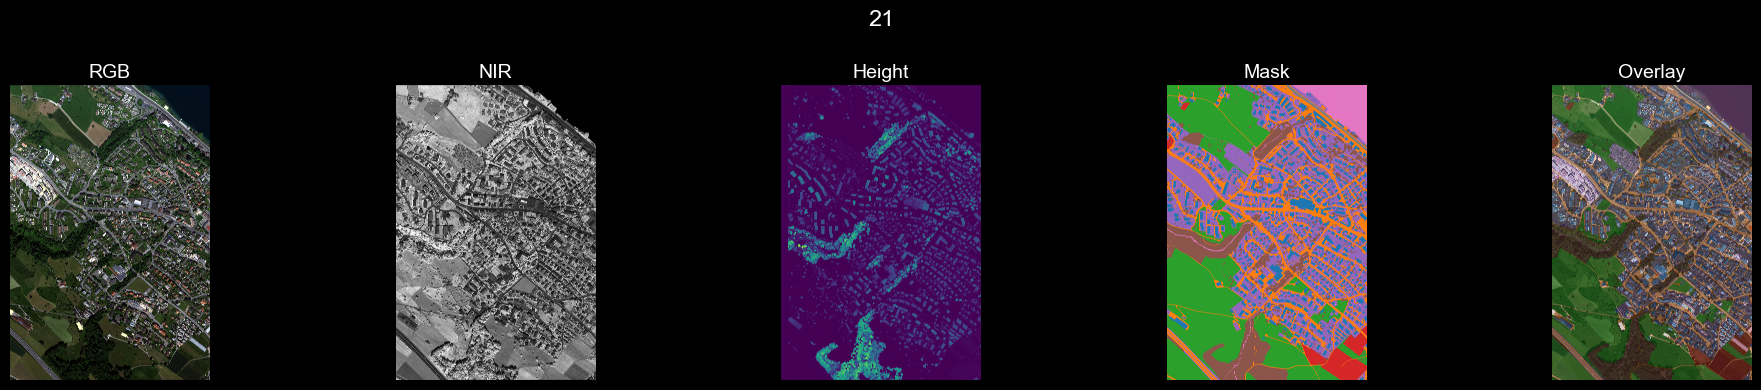

In [69]:
# Visual sanity check (compact)

required = ["img_files", "mask_files", "tile_id"]

n_samples = 1
rng = np.random.default_rng(42)

mask_lookup = {tile_id(p): p for p in mask_files}
sample_img_files = rng.choice(img_files, size=min(n_samples, len(img_files)), replace=False)

def normalize_rgb(rgb):
    rgb = rgb.astype(np.float32)
    lo = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

for img_file in sample_img_files:
    t_id = tile_id(img_file)
    mask_file = mask_lookup.get(t_id)
    if mask_file is None:
        continue

    with rasterio.open(img_file) as src:
        img = src.read().transpose(1, 2, 0)  # (H, W, C)
    with rasterio.open(mask_file) as src:
        m = src.read(1)  # (H, W)

    rgb = normalize_rgb(img[:, :, 1:4])
    nir_raw = img[:, :, 0].astype(np.float32)
    lo, hi = np.percentile(nir_raw[nir_raw > 0], [1, 99]) if np.any(nir_raw > 0) else (nir_raw.min(), nir_raw.max())
    nir = np.clip((nir_raw - lo) / (hi - lo + 1e-6), 0, 1)
    h = img[:, :, 4] if img.shape[2] > 4 else None

    ncols = 5 if h is not None else 4
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    axes[1].imshow(nir, cmap=CONFIG["CMAP_IMAGE"])
    axes[1].set_title("NIR")
    axes[1].axis("off")

    k = 2
    if h is not None:
        axes[2].imshow(h, cmap="viridis")
        axes[2].set_title("Height")
        axes[2].axis("off")
        k = 3

    axes[k].imshow(m, cmap=CONFIG["CMAP_MASK"], vmin=1, vmax=8)
    axes[k].set_title("Mask")
    axes[k].axis("off")

    axes[k + 1].imshow(rgb)
    axes[k + 1].imshow(m, cmap=CONFIG["CMAP_MASK"], vmin=1, vmax=8, alpha=0.35)
    axes[k + 1].set_title("Overlay")
    axes[k + 1].axis("off")

    fig.suptitle(t_id)
    plt.tight_layout()
    plt.show()

## 4) Descriptive Statistics (Channels and Pixel Distributions)

**Goal:** characterize intensity and height distributions to guide normalization and augmentation.

### Recommended analyses
- Per-channel mean, std, min, max, percentiles
- Histograms and KDE curves
- Image-level distribution variability (full scenes)
- Optional stratification by class and by spatial subset

Use robust statistics (median/IQR) in addition to mean/std.

images=4 | channels=5


,channel,mean,std,min,max,p5,p50,p95
0,NIR,2676.192764,1831.827161,1.0,65535.0,140.95,2406.0,5728.05
1,Red,1181.697848,1103.491910,1.0,65535.0,277.00,889.0,2886.05
2,Green,1538.126155,1125.906185,1.0,65535.0,551.00,1352.0,3063.05
3,Blue,1437.142335,1016.046675,1.0,65535.0,756.00,1099.0,2822.00
4,Height,637.949723,834.361066,1.0,6583.0,6.00,283.0,2538.15


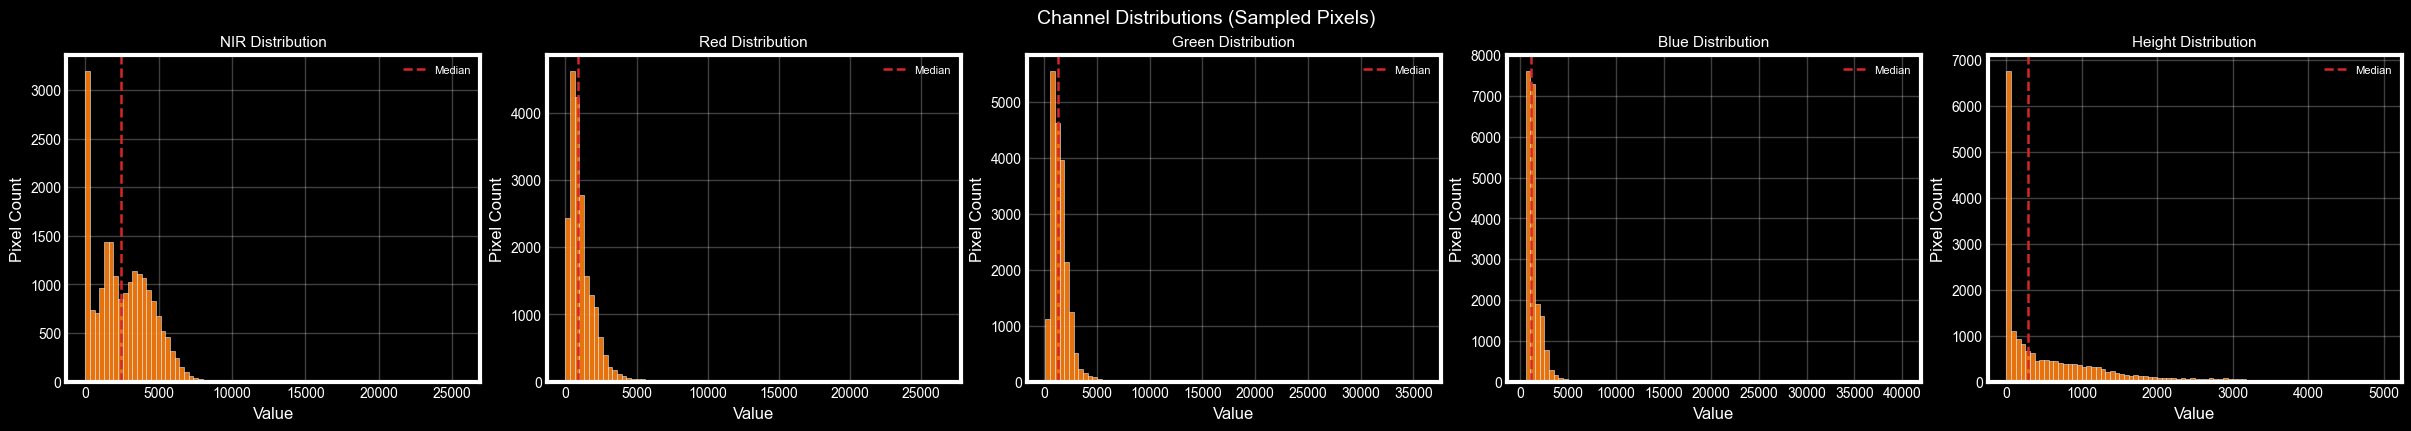

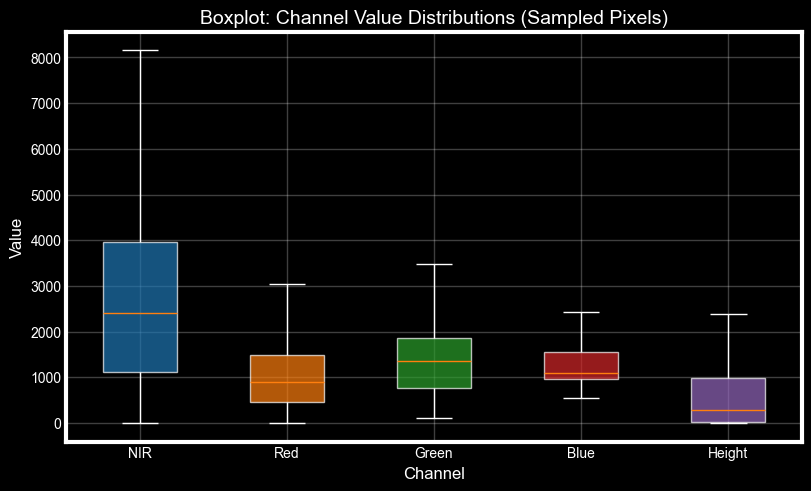

In [74]:
# Descriptive statistics for full images (no tiles)

if "img_files" not in globals():
    root_path = "A:/STUDIUM/06_Fruelingssemester26/BA/"
    images_path = os.path.join(root_path, "data/aerial/Buffered_images/images")
    img_files = sorted([os.path.join(images_path, f) for f in os.listdir(images_path) if f.endswith(".tif")])

with rasterio.open(img_files[0]) as src0:
    n_channels = src0.count

default_names = ["NIR", "Red", "Green", "Blue", "Height"]
channel_names = default_names[:n_channels] + [f"Ch{i+1}" for i in range(len(default_names), n_channels)]

sum_v = np.zeros(n_channels, dtype=np.float64)
sum_sq_v = np.zeros(n_channels, dtype=np.float64)
count_v = np.zeros(n_channels, dtype=np.float64)
min_v = np.full(n_channels, np.inf, dtype=np.float64)
max_v = np.full(n_channels, -np.inf, dtype=np.float64)

sample_per_image = 5000
rng = np.random.default_rng(42)
samples = [[] for _ in range(n_channels)]

for img_file in img_files:
    with rasterio.open(img_file) as src:
        arr = src.read().astype(np.float32)  # (C, H, W)
        nodata = src.nodata

    for ch in range(n_channels):
        vals = arr[ch].ravel()
        valid = np.isfinite(vals)
        if nodata is not None:
            valid &= vals != nodata
        vals = vals[valid]

        if vals.size == 0:
            continue

        vals64 = vals.astype(np.float64)
        sum_v[ch] += vals64.sum()
        sum_sq_v[ch] += np.square(vals64).sum()
        count_v[ch] += vals64.size
        min_v[ch] = min(min_v[ch], float(vals64.min()))
        max_v[ch] = max(max_v[ch], float(vals64.max()))

        take = min(sample_per_image, vals64.size)
        idx = rng.choice(vals64.size, size=take, replace=False)
        samples[ch].append(vals64[idx])

means = sum_v / np.maximum(count_v, 1)
vars_ = (sum_sq_v / np.maximum(count_v, 1)) - np.square(means)
stds = np.sqrt(np.clip(vars_, 0, None))

rows = []
for ch in range(n_channels):
    if len(samples[ch]) > 0:
        s = np.concatenate(samples[ch])
        p5, p50, p95 = np.percentile(s, [5, 50, 95])
    else:
        p5 = p50 = p95 = np.nan

    rows.append({
        "channel": channel_names[ch],
        "mean": float(means[ch]),
        "std": float(stds[ch]),
        "min": float(min_v[ch]) if np.isfinite(min_v[ch]) else np.nan,
        "max": float(max_v[ch]) if np.isfinite(max_v[ch]) else np.nan,
        "p5": float(p5),
        "p50": float(p50),
        "p95": float(p95),
    })

global_stats = pd.DataFrame(rows)

print(f"images={len(img_files)} | channels={n_channels}")
display(global_stats)

fig, axes = plt.subplots(1, n_channels, figsize=(4.8 * n_channels, 4.2), constrained_layout=True)
if n_channels == 1:
    axes = [axes]

hist_color = CONFIG["PALETTE"][1]
median_color = CONFIG["PALETTE"][3]

for ch in range(n_channels):
    ax = axes[ch]
    if len(samples[ch]) > 0:
        s = np.concatenate(samples[ch])
        ax.hist(s, bins=80, color=hist_color, alpha=0.9, edgecolor="white", linewidth=0.4)
        med = np.median(s)
        ax.axvline(med, color=median_color, linestyle="--", linewidth=1.8, label="Median")
        ax.legend(loc="upper right", fontsize=8)
    ax.set_title(f"{channel_names[ch]} Distribution", fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Pixel Count")
    ax.grid(True, alpha=0.25)

fig.suptitle("Channel Distributions (Sampled Pixels)", fontsize=14)
plt.show()

# Additional boxplot for channel distributions
box_data = [np.concatenate(samples[ch]) for ch in range(n_channels) if len(samples[ch]) > 0]
box_labels = [channel_names[ch] for ch in range(n_channels) if len(samples[ch]) > 0]

if len(box_data) > 0:
    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(box_data)), 4.8), constrained_layout=True)
    bp = ax.boxplot(box_data, patch_artist=True, tick_labels=box_labels, showfliers=False)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(CONFIG["PALETTE"][i % len(CONFIG["PALETTE"])])
        patch.set_alpha(0.7)
    ax.set_title("Boxplot: Channel Value Distributions (Sampled Pixels)")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.25)
    plt.show()

# Optional export
# global_stats.to_csv("channel_stats_global.csv", index=False)

## 5) Label Distribution, Class Imbalance, and Boundary Complexity

**Goal:** quantify class frequencies and understand segmentation difficulty.

### Recommended analyses
- Global pixel count per class
- Per-tile class proportions
- Rare-class identification
- Boundary complexity proxies (edge length, fragmentation)

These results are needed to justify loss weighting, sampling strategy, and evaluation metrics.

masks=4 | total_known_pixels=585,387,106 | total_unknown_pixels=10


,class_id,class_name,pixels,pct
0,1,Building,52502310,8.968819
1,2,Impervious_Surface,90428628,15.447663
2,3,Cropland,114760137,19.604145
3,4,Intensive_Culture,33440345,5.712518
4,5,Grassland_Garden,122023950,20.845001
5,6,Tree_Canopy,81306120,13.889291
6,7,Water,85156214,14.546992
7,8,Railway,5769402,0.985570


Rare classes: Railway (0.99%)


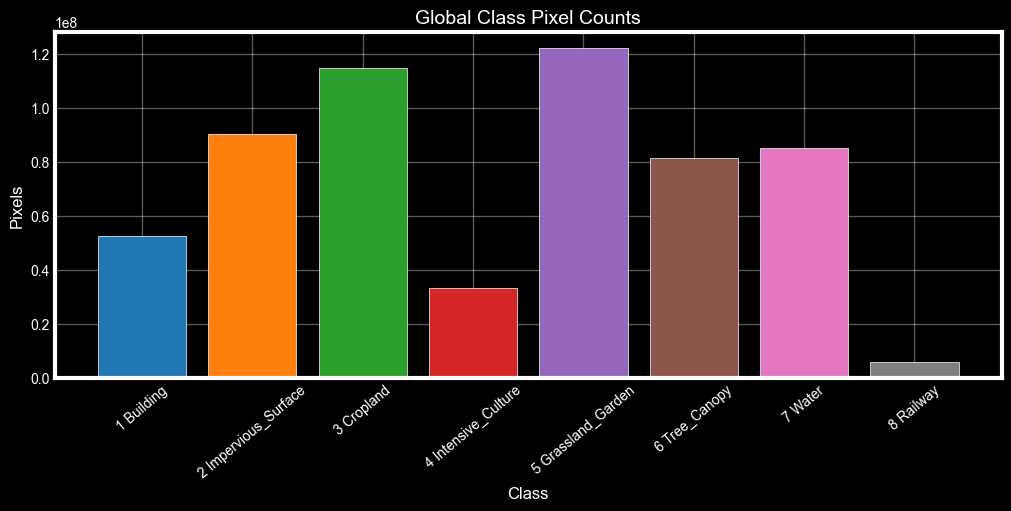

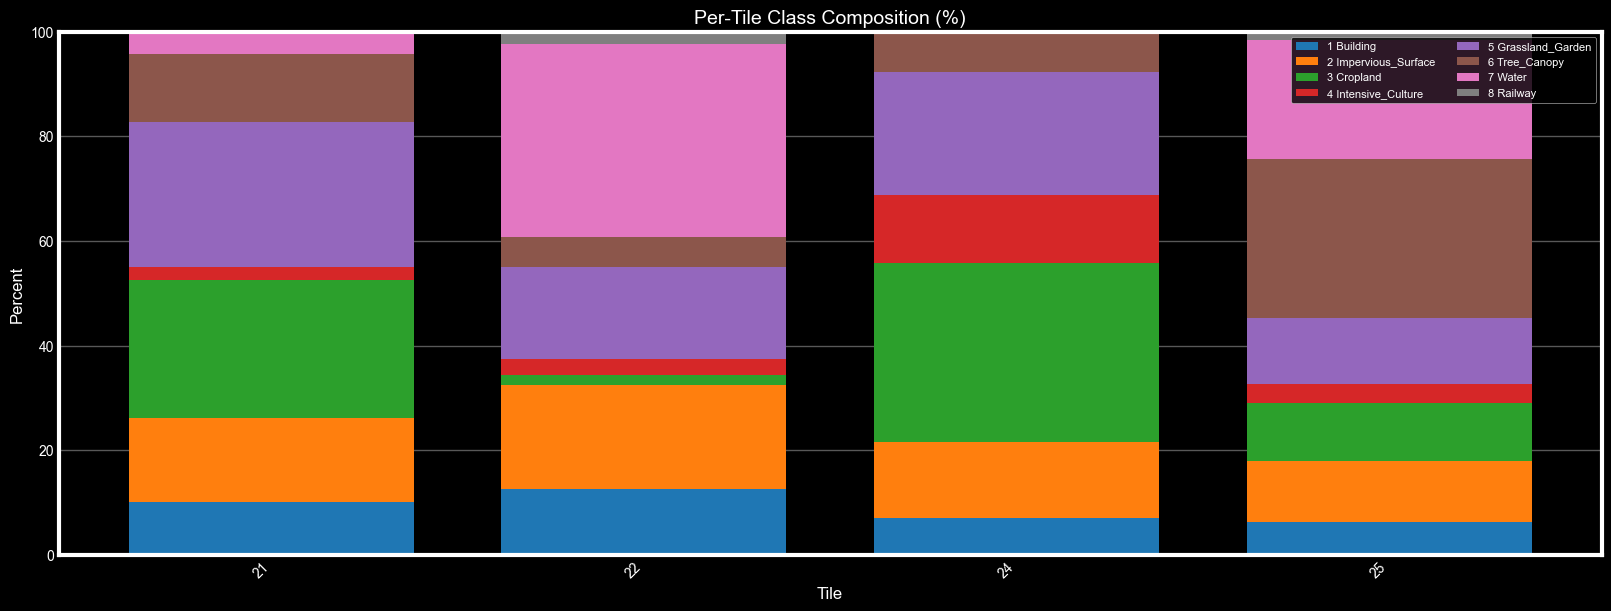

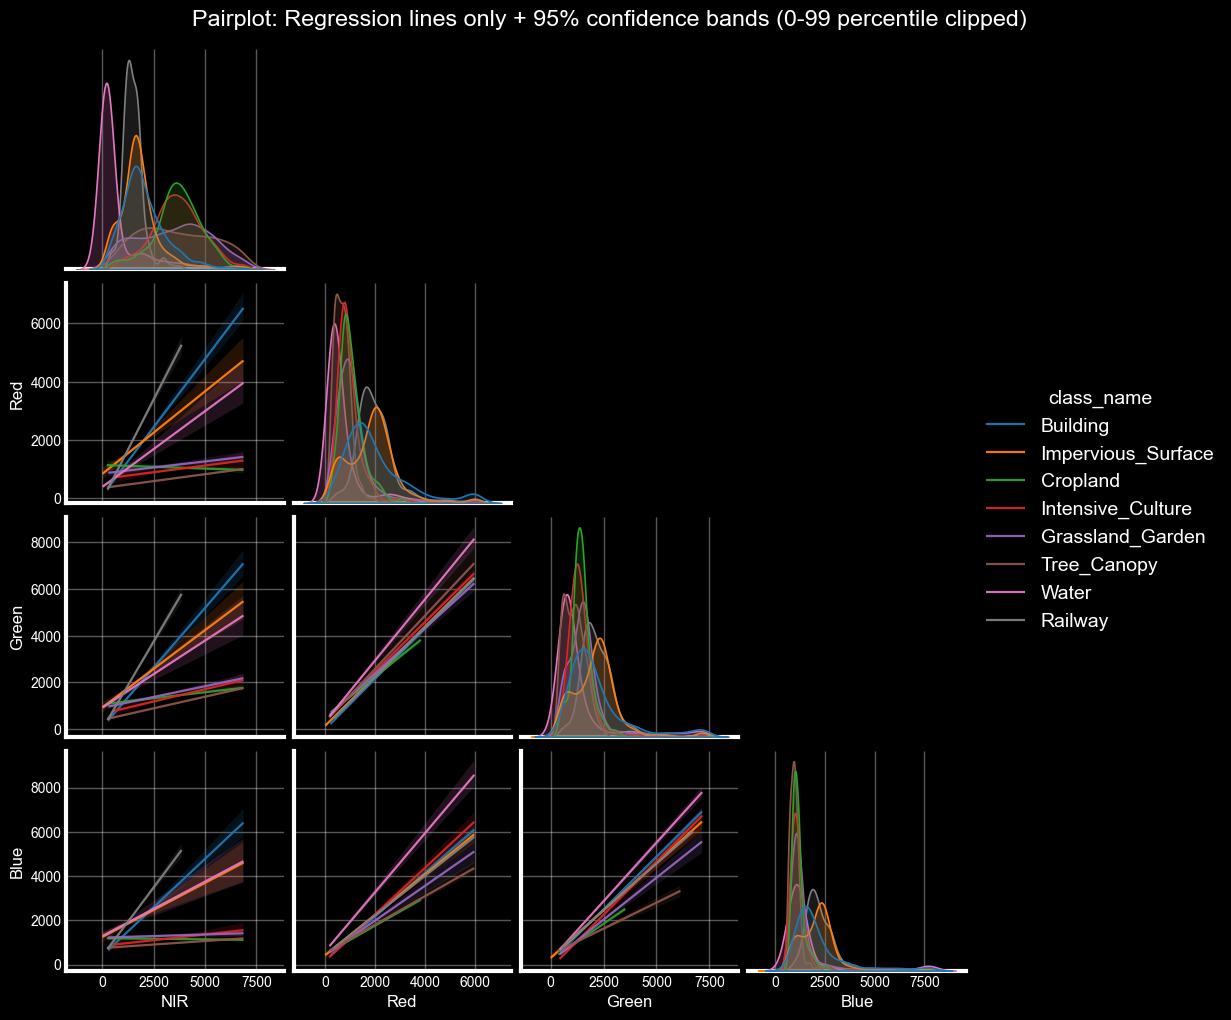

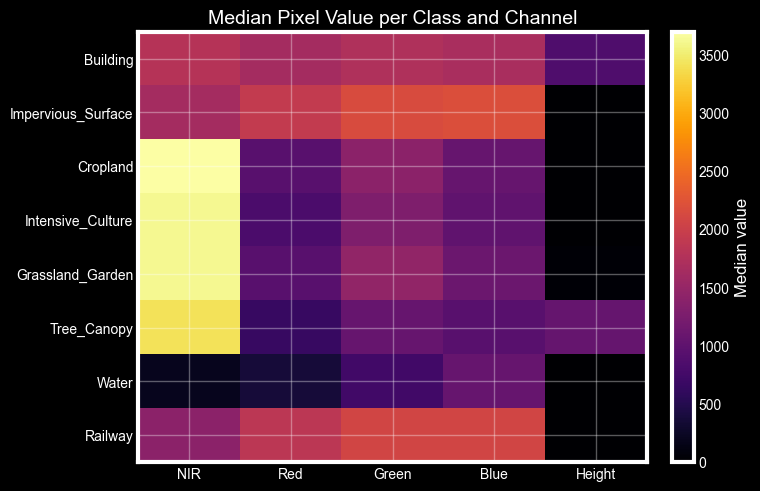

In [85]:
# Label distribution and class imbalance analysis

# Fallback: build file lists if not already available
if "mask_files" not in globals():
    root_path = "A:/STUDIUM/06_Fruelingssemester26/BA/"
    masks_path = os.path.join(root_path, "data/aerial/Buffered_images/masks")
    mask_files = sorted([os.path.join(masks_path, f) for f in os.listdir(masks_path) if f.endswith(".tif")])

if "img_files" not in globals():
    root_path = "A:/STUDIUM/06_Fruelingssemester26/BA/"
    images_path = os.path.join(root_path, "data/aerial/Buffered_images/images")
    img_files = sorted([os.path.join(images_path, f) for f in os.listdir(images_path) if f.endswith(".tif")])

if "tile_id" not in globals():
    def tile_id(file_path):
        s = Path(file_path).stem.lower()
        s = re.sub(r"^(clipped_stacked_buffered_|mask_)", "", s)
        return s

class_map = CONFIG.get("CLASS_NAMES", {
    1: "Building",
    2: "Impervious_Surface",
    3: "Cropland",
    4: "Intensive_Culture",
    5: "Grassland_Garden",
    6: "Tree_Canopy",
    7: "Water",
    8: "Railway",
})
class_ids = sorted(class_map.keys())
class_name_order = [class_map[cid] for cid in class_ids]
class_cols = [f"class_{cid}" for cid in class_ids]

rows = []
for mf in mask_files:
    with rasterio.open(mf) as src:
        m = src.read(1)

    vals = m[np.isfinite(m)].astype(np.int32)
    u, c = np.unique(vals, return_counts=True)
    cnt = {int(k): int(v) for k, v in zip(u, c)}

    row = {
        "tile_id": tile_id(mf),
        "mask_file": mf,
    }
    for cid in class_ids:
        row[f"class_{cid}"] = cnt.get(cid, 0)

    known_pixels = sum(row[f"class_{cid}"] for cid in class_ids)
    unknown_pixels = int(sum(v for k, v in cnt.items() if k not in class_ids))
    row["known_pixels"] = known_pixels
    row["unknown_pixels"] = unknown_pixels
    row["unknown_pct"] = (100.0 * unknown_pixels / max(known_pixels + unknown_pixels, 1))
    rows.append(row)

per_tile_df = pd.DataFrame(rows).sort_values("tile_id").reset_index(drop=True)

# Global distribution (fixed class order)
global_counts = per_tile_df[class_cols].sum(axis=0)
global_total = int(global_counts.sum())
global_df = pd.DataFrame({
    "class_id": class_ids,
    "class_name": class_name_order,
    "pixels": [int(global_counts[f"class_{cid}"]) for cid in class_ids],
})
global_df["pct"] = 100.0 * global_df["pixels"] / max(global_total, 1)

# Per-tile percentages
for cid in class_ids:
    per_tile_df[f"pct_{cid}"] = 100.0 * per_tile_df[f"class_{cid}"] / np.maximum(per_tile_df["known_pixels"], 1)

# Rare classes (threshold in %)
rare_threshold_pct = 1.0
rare_df = global_df[global_df["pct"] < rare_threshold_pct].copy()

print(f"masks={len(mask_files)} | total_known_pixels={global_total:,} | total_unknown_pixels={int(per_tile_df['unknown_pixels'].sum()):,}")
display(global_df[["class_id", "class_name", "pixels", "pct"]])
if len(rare_df) > 0:
    print("Rare classes:", ", ".join([f"{r.class_name} ({r.pct:.2f}%)" for r in rare_df.itertuples(index=False)]))
else:
    print(f"No rare classes below {rare_threshold_pct}%. ")

# ---- Plot 1: global class counts (linear only, fixed class order) ----
bar_colors = [CONFIG["PALETTE"][(cid - 1) % len(CONFIG["PALETTE"])] for cid in class_ids]
xlabels = [f"{cid} {class_map[cid]}" for cid in class_ids]

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.bar(xlabels, global_df["pixels"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_title("Global Class Pixel Counts")
ax.set_xlabel("Class")
ax.set_ylabel("Pixels")
ax.tick_params(axis="x", rotation=40)
plt.show()

# ---- Plot 2: per-tile stacked class percentages (10% narrower bars) ----
fig, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
bottom = np.zeros(len(per_tile_df), dtype=float)
x = np.arange(len(per_tile_df))

for cid in class_ids:
    vals = per_tile_df[f"pct_{cid}"].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        width=0.765,
        label=f"{cid} {class_map[cid]}",
        color=CONFIG["PALETTE"][(cid - 1) % len(CONFIG["PALETTE"])],
    )
    bottom += vals

ax.set_title("Per-Tile Class Composition (%)")
ax.set_xlabel("Tile")
ax.set_ylabel("Percent")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(per_tile_df["tile_id"], rotation=45, ha="right")
ax.legend(ncol=2, fontsize=8, frameon=True)
plt.show()

# ---- Plot 3A: class vs pixel values (pairplot, clipped to 0-99 percentile) ----
image_lookup = {tile_id(p): p for p in img_files}

sample_per_class_per_tile = 350
sample_tables = []

for mf in mask_files:
    tid = tile_id(mf)
    img_path = image_lookup.get(tid)
    if img_path is None:
        continue

    with rasterio.open(mf) as msrc:
        mask = msrc.read(1)
    with rasterio.open(img_path) as isrc:
        img = isrc.read().astype(np.float32)  # (C, H, W)

    n_ch = img.shape[0]
    ch_names = ["NIR", "Red", "Green", "Blue", "Height"][:n_ch]
    if len(ch_names) < n_ch:
        ch_names += [f"Ch{i+1}" for i in range(len(ch_names), n_ch)]

    for cid in class_ids:
        rr, cc = np.where(mask == cid)
        if rr.size == 0:
            continue

        take = min(sample_per_class_per_tile, rr.size)
        idx = rng.choice(rr.size, size=take, replace=False)
        rsel = rr[idx]
        csel = cc[idx]

        vals = img[:, rsel, csel].T
        tmp = pd.DataFrame(vals, columns=ch_names)
        tmp["class_id"] = cid
        tmp["class_name"] = class_map[cid]
        sample_tables.append(tmp)

if len(sample_tables) > 0:
    pair_df = pd.concat(sample_tables, ignore_index=True)
    pair_vars = [c for c in ["NIR", "Red", "Green", "Blue"] if c in pair_df.columns]

    # Fix class order for all class-based plots
    pair_df["class_name"] = pd.Categorical(pair_df["class_name"], categories=class_name_order, ordered=True)

    if len(pair_vars) >= 2:
        # limit points to keep pairplot responsive
        max_rows = 5000
        if len(pair_df) > max_rows:
            pair_df = pair_df.sample(n=max_rows, random_state=42)

        # Readability: clip each channel to its [0th, 99th] percentile range
        for var in pair_vars:
            lo = np.percentile(pair_df[var], 0)
            hi = np.percentile(pair_df[var], 99)
            pair_df[var] = np.clip(pair_df[var], lo, hi)

        # Regression lines only (no scatter points) + transparent filled density diagonals
        g = sns.pairplot(
            data=pair_df,
            vars=pair_vars,
            kind="reg",
            hue="class_name",
            hue_order=class_name_order,
            corner=True,
            plot_kws={
                "scatter": False,
                "line_kws": {"linewidth": 1.6, "alpha": 0.95},
                "ci": 95,
            },
            diag_kind="kde",
            diag_kws={"fill": True, "alpha": 0.20, "linewidth": 1.2, "common_norm": False},
        )
        g.fig.suptitle("Pairplot: Regression lines only + 95% confidence bands (0-99 percentile clipped)", y=1.02)
        plt.show()

        # ---- Plot 3B (alternative): class-wise median heatmap incl. Height ----
        heat_vars = [c for c in ["NIR", "Red", "Green", "Blue", "Height"] if c in pair_df.columns]
        med = pair_df.groupby("class_name", observed=False)[heat_vars].median().reindex(class_name_order)
        fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
        im = ax.imshow(med.values, aspect="auto", cmap="inferno")
        ax.set_title("Median Pixel Value per Class and Channel")
        ax.set_xticks(np.arange(len(heat_vars)))
        ax.set_xticklabels(heat_vars, rotation=0)
        ax.set_yticks(np.arange(len(med.index)))
        ax.set_yticklabels(med.index)
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Median value")
        plt.show()
else:
    print("No paired image-mask samples available for class-vs-pixel plots.")

# Optional exports
# global_df.to_csv("class_distribution_global.csv", index=False)
# per_tile_df.to_csv("class_distribution_per_tile.csv", index=False)

## 6) Missing Data, NoData, and Invalid Value Analysis

**Goal:** identify missing, invalid, or suspicious values that may destabilize training.

### Recommended checks
- NoData proportion per channel and per tile
- NaN/Inf counts
- Out-of-range values
- Mask values outside valid class IDs
- Spatial concentration of invalid pixels

Summarize problematic tiles in a dedicated quality-issue table.

In [ ]:
# ================================================
# TODO: Implement missing/NoData/invalid-value analysis
# ================================================

## TODO: Compute NaN, Inf, and NoData statistics
## - per channel
## - per tile

## TODO: Check value ranges
## - detect impossible values by channel
## - report top offending tiles

## TODO: Validate masks
## - detect 0 or negative values (if not expected)
## - detect class IDs > 8

## TODO: Visualize invalid-value maps
## - heatmaps or binary masks of invalid pixels

## TODO: Save an issue log
## Suggested columns: tile_id, issue_type, affected_pixels, severity

## 7) Correlation Matrix and Feature Redundancy

**Goal:** quantify inter-channel relationships and identify redundant signals.

### Recommended analyses
- Pearson and Spearman correlation on sampled pixels
- Correlation by class (optional)
- Correlation by tile (optional)
- Multicollinearity diagnostics (e.g., VIF on engineered features)

Use stratified pixel sampling to avoid class-dominance bias.

In [ ]:
# ================================================
# TODO: Implement correlation analysis
# ================================================

## TODO: Sample pixels for correlation analysis
## - random or stratified by class
## - keep memory constraints under control

## TODO: Build a feature table with columns
## [NIR, Red, Green, Blue, Height] (+ optional engineered features)

## TODO: Compute correlation matrices
## - Pearson
## - Spearman

## TODO: Visualize correlations
## - heatmaps with annotations
## - clustered heatmap for redundancy patterns

## TODO: (Optional) compute VIF or similar redundancy diagnostics

## TODO: Export correlation tables and figures

## 8) Feature Importance for Segmentation-Relevant Signals

**Goal:** estimate which channels/features drive predictive performance.

Because segmentation is spatial and non-linear, use multiple complementary methods.

### Recommended methods
1. **Classical baseline (tabular proxy):** Random Forest on sampled pixels/features
2. **Permutation importance (model-based):** permute channels and measure metric drop
3. **Explainability methods:** SHAP or gradient-based attribution on selected patches

Report global and class-specific importance whenever possible.

In [ ]:
# ================================================
# TODO: Implement feature-importance analyses
# ================================================

## TODO: Build a tabular proxy dataset
## - features: channels (+ engineered texture/height features)
## - target: class label from mask
## - stratified sampling for class balance

## TODO: Train a baseline model for proxy importance
## - e.g., RandomForest / XGBoost
## - evaluate quickly and compute feature importances

## TODO: Implement permutation channel importance on segmentation model
## - for each channel: permute values in validation set
## - measure metric drop (IoU/F1)
## - report ranking and confidence intervals

## TODO: (Optional) add SHAP/attribution analysis on selected tiles
## - global summary plot
## - per-class interpretation examples

## TODO: Save all outputs
## - feature_importance_table.csv
## - permutation_importance_plot.png
## - attribution_examples/

## 9) Split Strategy, Leakage Checks, and Distribution Shift

**Goal:** ensure train/validation/test splits are independent and representative.

### Recommended checks
- No tile overlap across splits
- No spatial-neighbor leakage (if overlap buffers exist)
- Similar class distribution across splits
- Similar channel statistics across splits
- Temporal/flight-path grouping consistency (if available)

A good split is as important as model architecture for trustworthy evaluation.

In [ ]:
# ================================================
# TODO: Implement split-quality and leakage checks
# ================================================

## TODO: Define or load split assignment
## - train/val/test by tile_id or spatial group

## TODO: Verify strict separation
## - no duplicated tile IDs across splits
## - no overlapping raster footprints across splits (if relevant)

## TODO: Compare distributions per split
## - class frequencies
## - channel means/std
## - optional statistical tests (KS, chi-square)

## TODO: Visualize split differences
## - side-by-side bar plots and density plots

## TODO: Save split quality report
## Include leakage flags and recommended fixes if needed

## 10) Robustness Checks (Augmentation and Domain Shift Readiness)

**Goal:** evaluate whether preprocessing and augmentation plans are aligned with real data variability.

### Recommended checks
- Simulate realistic intensity and geometric perturbations
- Check class stability under perturbations
- Verify that rare classes remain visible after augmentation
- Identify channels most sensitive to perturbation

Document augmentation limits to avoid unrealistic transformations.

In [ ]:
# ================================================
# TODO: Implement robustness and augmentation checks
# ================================================

## TODO: Define a small perturbation benchmark
## Examples: brightness shift, contrast shift, mild blur, noise, geometric transforms

## TODO: Measure distribution changes after perturbation
## - channel statistics before/after
## - class visibility and boundary integrity

## TODO: Assess potential augmentation risks
## - unrealistic artifacts
## - class confusion introduced by augmentation

## TODO: Document safe augmentation ranges
## Produce a concise recommendation table for training config

## 11) Outlier Mining and Hard-Case Discovery

**Goal:** identify tiles/pixels that are likely to fail during model training or inference.

### Recommended analyses
- Tiles with extreme channel statistics
- Tiles with unusual class composition
- High boundary complexity or noisy labels
- Potential geolocation misalignment indicators

Use this section to define a manual review shortlist.

In [ ]:
# ================================================
# TODO: Implement outlier and hard-case analysis
# ================================================

## TODO: Build tile-level feature summary
## - channel stats, class ratios, texture proxies, invalid-pixel rates

## TODO: Run unsupervised outlier scoring
## Examples: Isolation Forest, Local Outlier Factor, robust z-scores

## TODO: Rank and inspect top-N outlier tiles
## - visualize image/mask overlays
## - document potential root causes

## TODO: Create a manual review list
## Include tile_id, reason_for_review, recommended_action

## 12) Final Model-Readiness Report

**Goal:** turn analysis outputs into actionable decisions for training.

### Include in your final summary
- Data strengths and known weaknesses
- Confirmed risks and mitigation plan
- Recommended preprocessing and normalization
- Recommended split strategy
- Recommended loss/weighting strategy for imbalance
- Priority list for manual relabeling/review

This section should be concise, evidence-based, and reproducible.

In [ ]:
# ================================================
# TODO: Write final recommendations and export artifacts
# ================================================

## TODO: Consolidate key metrics and findings
## - integrity pass/fail summary
## - imbalance summary
## - correlation and redundancy summary
## - feature importance summary

## TODO: Produce a final recommendation table
## Columns example: topic, finding, risk_level, recommended_action, priority

## TODO: Export final report assets
## - final_data_analysis_summary.md
## - final_recommendations.csv
## - figures/ and tables/ folders

## TODO: Add open questions and next actions for model development